In [142]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import glob

from hbn.visualization import visualize

import warnings
warnings.filterwarnings("ignore")

%load_ext autoreload
%autoreload 2

%matplotlib inline

#pio.renderers.default = 'iframe'
import plotly.io as pio
pio.renderers.default='notebook'

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [207]:
# check AGE models
from hbn.models.predictive_modeling import check_models

dirn = '/Users/maedbhking/Documents/hbn_data/models'
filter_model = 'adhd-age-models'
diagnosis_file = '/Users/maedbhking/Documents/hbn_data/Clinical_Diagnosis_Demographics.csv'

# hard code model diretory
df_all = check_models(dirn=dirn, 
            diagnosis_file=diagnosis_file,
            filter=f'*{filter_model}/*')
  
df_all['participant_group'] = df_all['sex'] + '_' + df_all['age']

In [208]:
# set plotting style
visualize.plotting_style()

## Age

<Axes: xlabel='age', ylabel='roc_auc_score'>

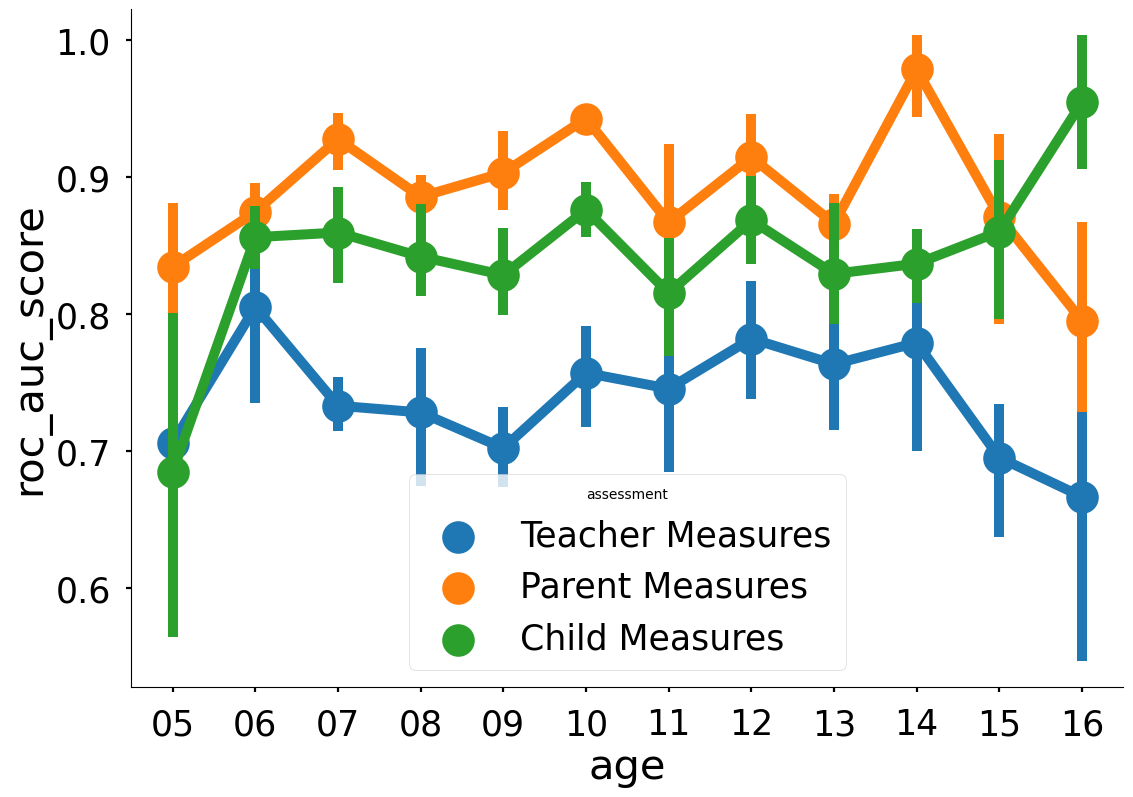

In [209]:
ages_to_keep = ['05', '06', '07', '08', '09', '10', '11', '12', '13', '14', '15', '16', '17']

df1 = df_all[(df_all['sex'].isin(['all'])) &
             (df_all['data']=='data') &
             (df_all['age'].isin(ages_to_keep)) &
             (df_all['assessment'].isin(['Parent Measures', 'Child Measures', 'Teacher Measures']))
            ]

sns.pointplot(x='age', y='roc_auc_score', hue='assessment', data=df1, order=sorted(df1['age'].unique()))

<Axes: xlabel='age', ylabel='roc_auc_score'>

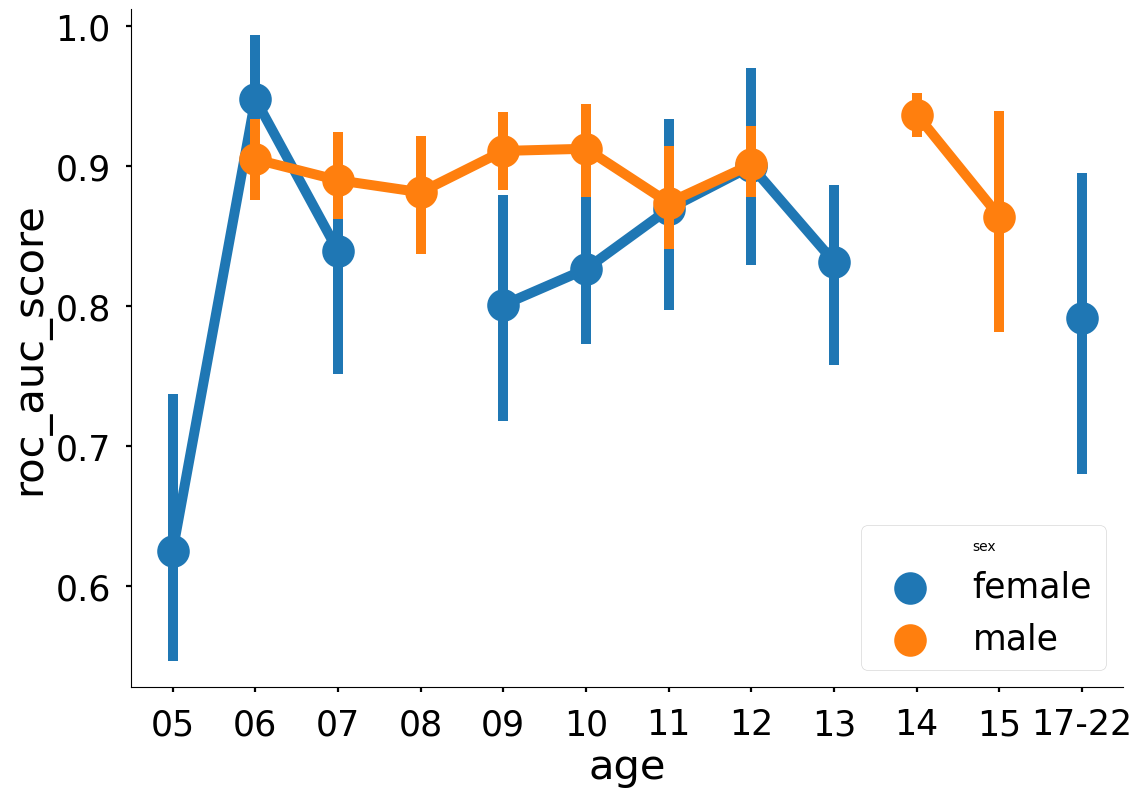

In [213]:
ages_to_keep = ['05', '06', '07', '08', '09', '10', '11', '12', '13', '14', '15', '16', '17-22']


df1 = df_all[(df_all['sex'].isin(['male', 'female'])) &
             (df_all['data']=='data') &
             (df_all['age'].isin(ages_to_keep)) &
             (df_all['assessment']=='all')
            ]

sns.pointplot(x='age', y='roc_auc_score', hue='sex', data=df1, order=sorted(df1['age'].unique()))

<Axes: xlabel='age', ylabel='roc_auc_score'>

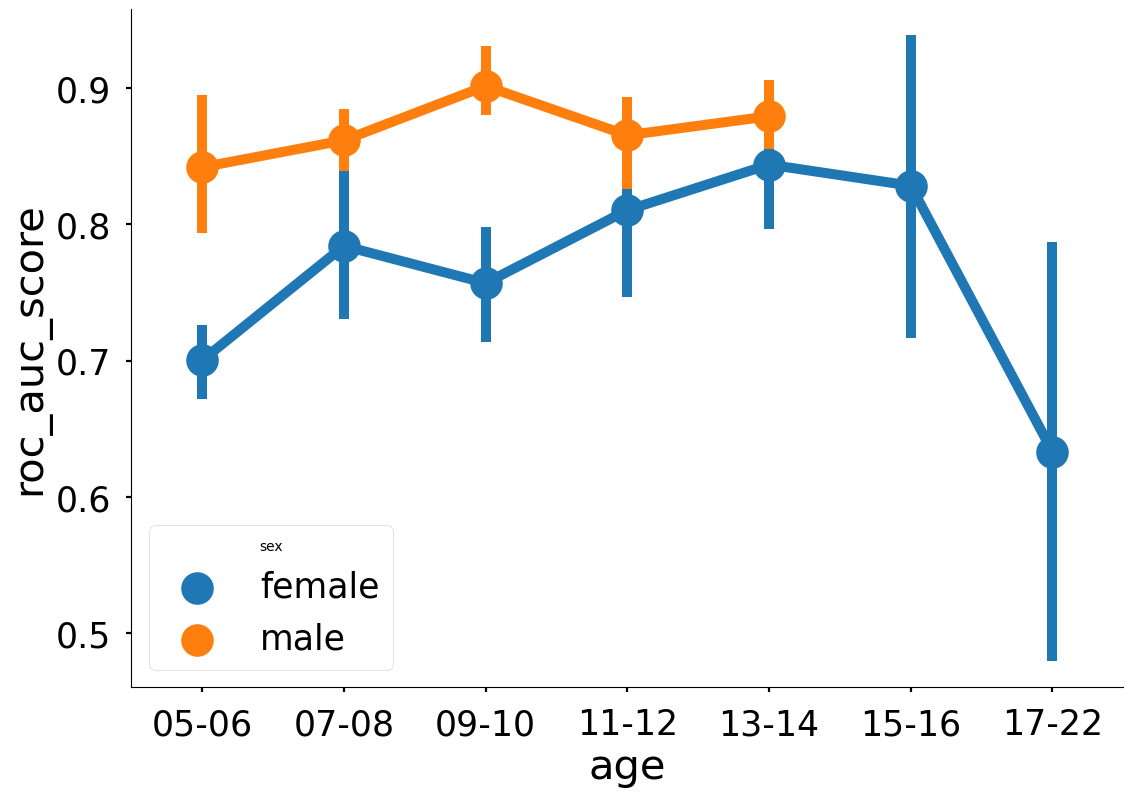

In [220]:
ages_to_keep = ['05-06', '07-08', '09-10', '11-12', '13-14', '15-16', '17-22']


df1 = df_all[(df_all['sex'].isin(['male', 'female'])) &
             (df_all['data']=='data') &
             (df_all['age'].isin(ages_to_keep)) &
             (df_all['assessment']=='Child Measures')
            ]

sns.pointplot(x='age', y='roc_auc_score', hue='sex', data=df1, order=sorted(df1['age'].unique()))

In [429]:
# check ADHD models
from hbn.models.predictive_modeling import check_models

dirn = '/Users/maedbhking/Documents/hbn_data/models'
filter_model = 'adhd-models'
diagnosis_file = '/Users/maedbhking/Documents/hbn_data/Clinical_Diagnosis_Demographics.csv'

# hard code model diretory
df_all = check_models(dirn=dirn, 
            diagnosis_file=diagnosis_file,
            filter=f'*{filter_model}/*')
  
df_all['participant_group'] = df_all['sex'] + '_' + df_all['age']
df_all['category_new'] = df_all['category'].str.replace('ADHD_', '').str.replace('_ADHD', '')


## Classification of ADHD for males and females (across different diagnoses)

In [430]:
# ## DEPRECIATED

# to_keep = ['Depressive Disorders', 'Anxiety Disorders', 'Autism Spectrum Disorder', 
#            'Specific Learning Disorder with Impairment in Reading', 'No Diagnosis Given']

# df1 = df_all[(df_all['sex'].isin(['male', 'female'])) &
#              (df_all['data']=='data') &
#              (df_all['assessment']=='all') &
#              (df_all['category'].apply(lambda x: any(s in to_keep for s in x)))
#             ].reset_index(drop=True)

# # make new column "category_new"
# for idx in df1.index:
#     list1 = set(to_keep)
#     list2 = set(df1.loc[idx, 'category'])
#     # get intersection between two lists and add to new column
#     df1.loc[idx, 'category_new'] = list(list1.intersection(list2))[0]
    

# ax = sns.violinplot(x='category_new', y='roc_auc_score', hue='sex', split=True, data=df1)
# plt.xticks(rotation=45, ha='right')
# ax.set_xlabel('')
# ax.set_ylabel('')
# ax.set_title('ADHD')
# plt.axhline(y=0.5, color='k', linestyle='--')
# ax.set_ylim([0.4, 1])

## Classifying ADHD from other diagnoses

In these models, ADHD is classified from a number of diagnoses (ASD, Depression, No Diagnosis etc.).
* Parent Measures: Males are always etter classified than females except for ADHD/ASD in which females are better classified
* Child Measures: same result for child measurse, except that females are only slightly better than males when classifying ADHD/ASD
* Teacher Measures: no sig. difference between males and females for both classifications except ADHD/ASD where females are better classified

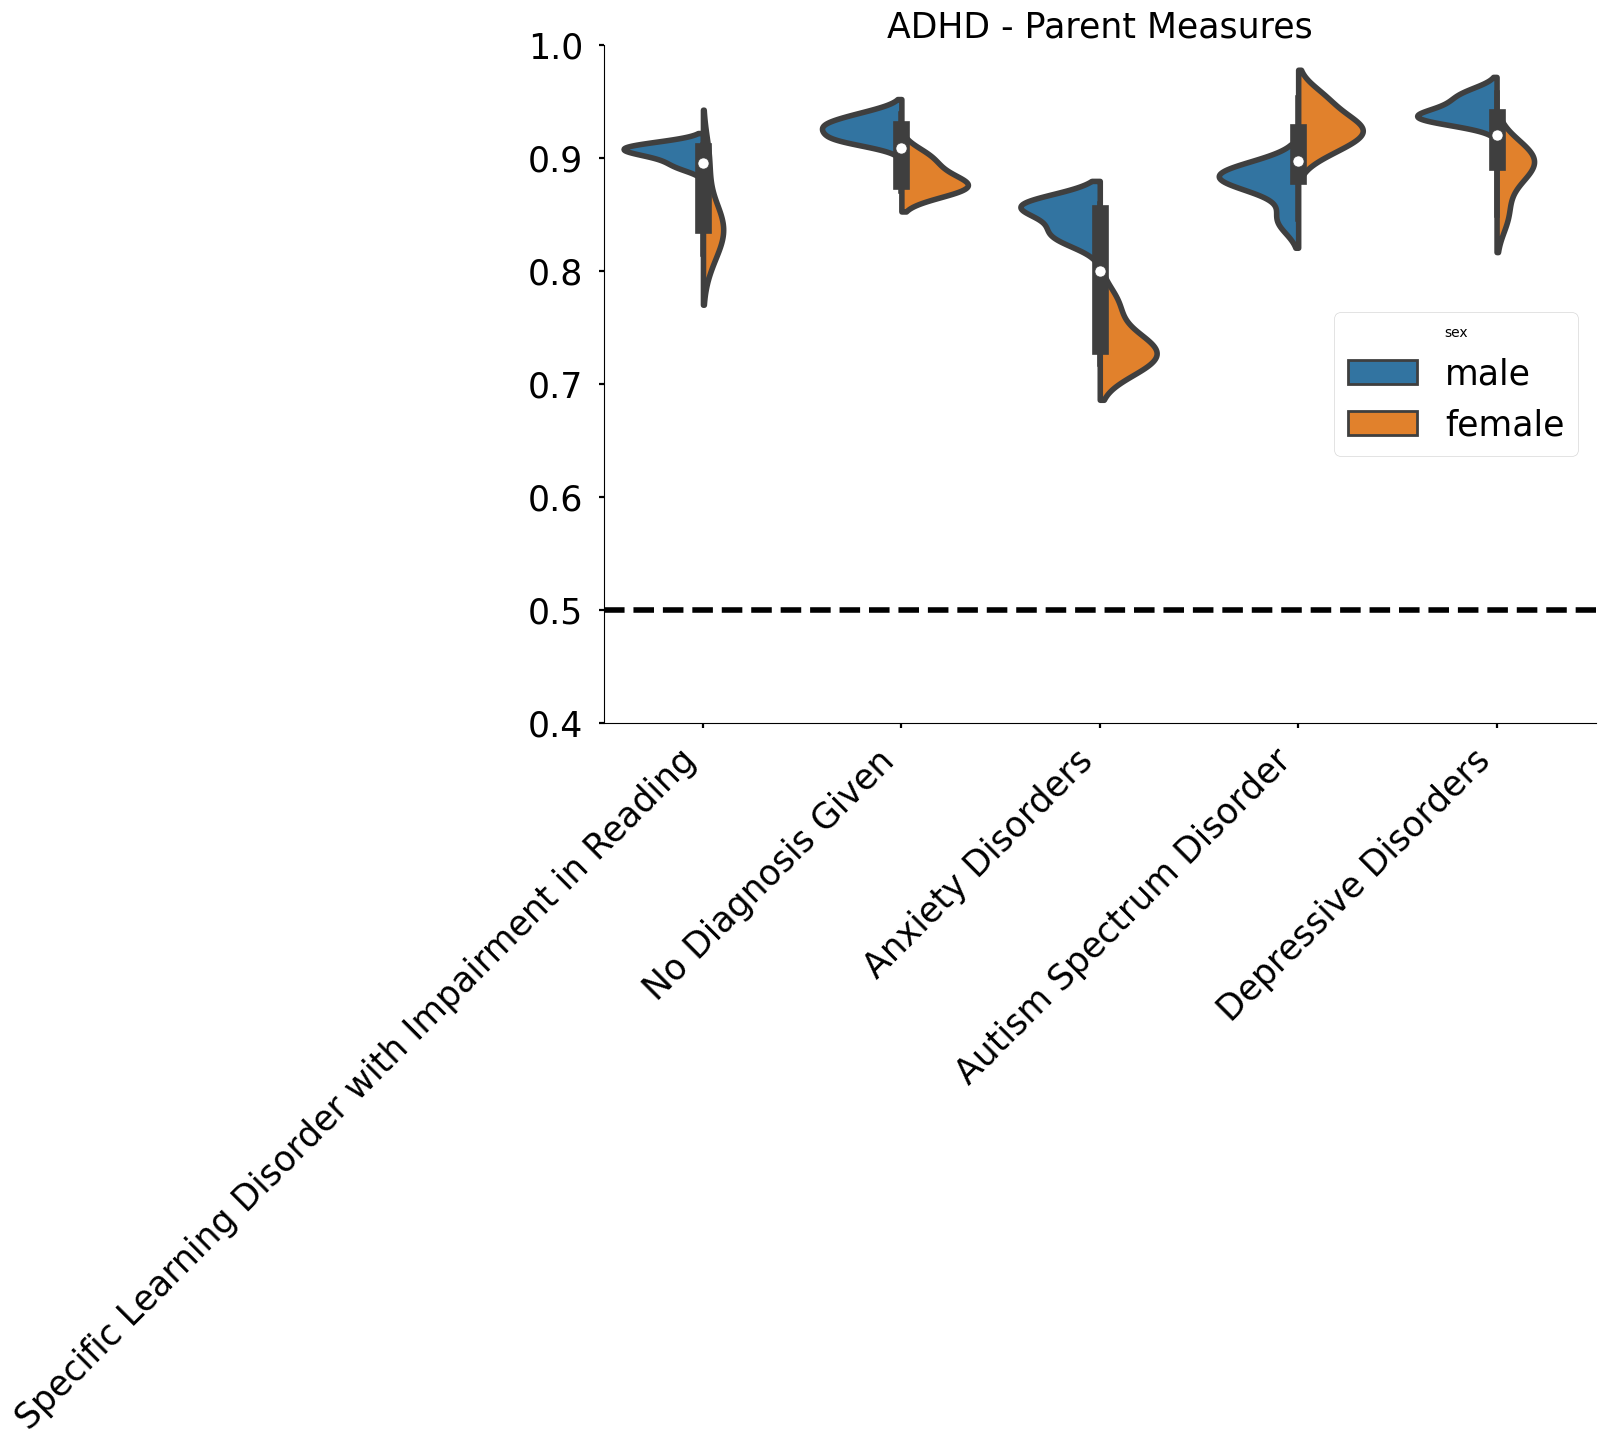

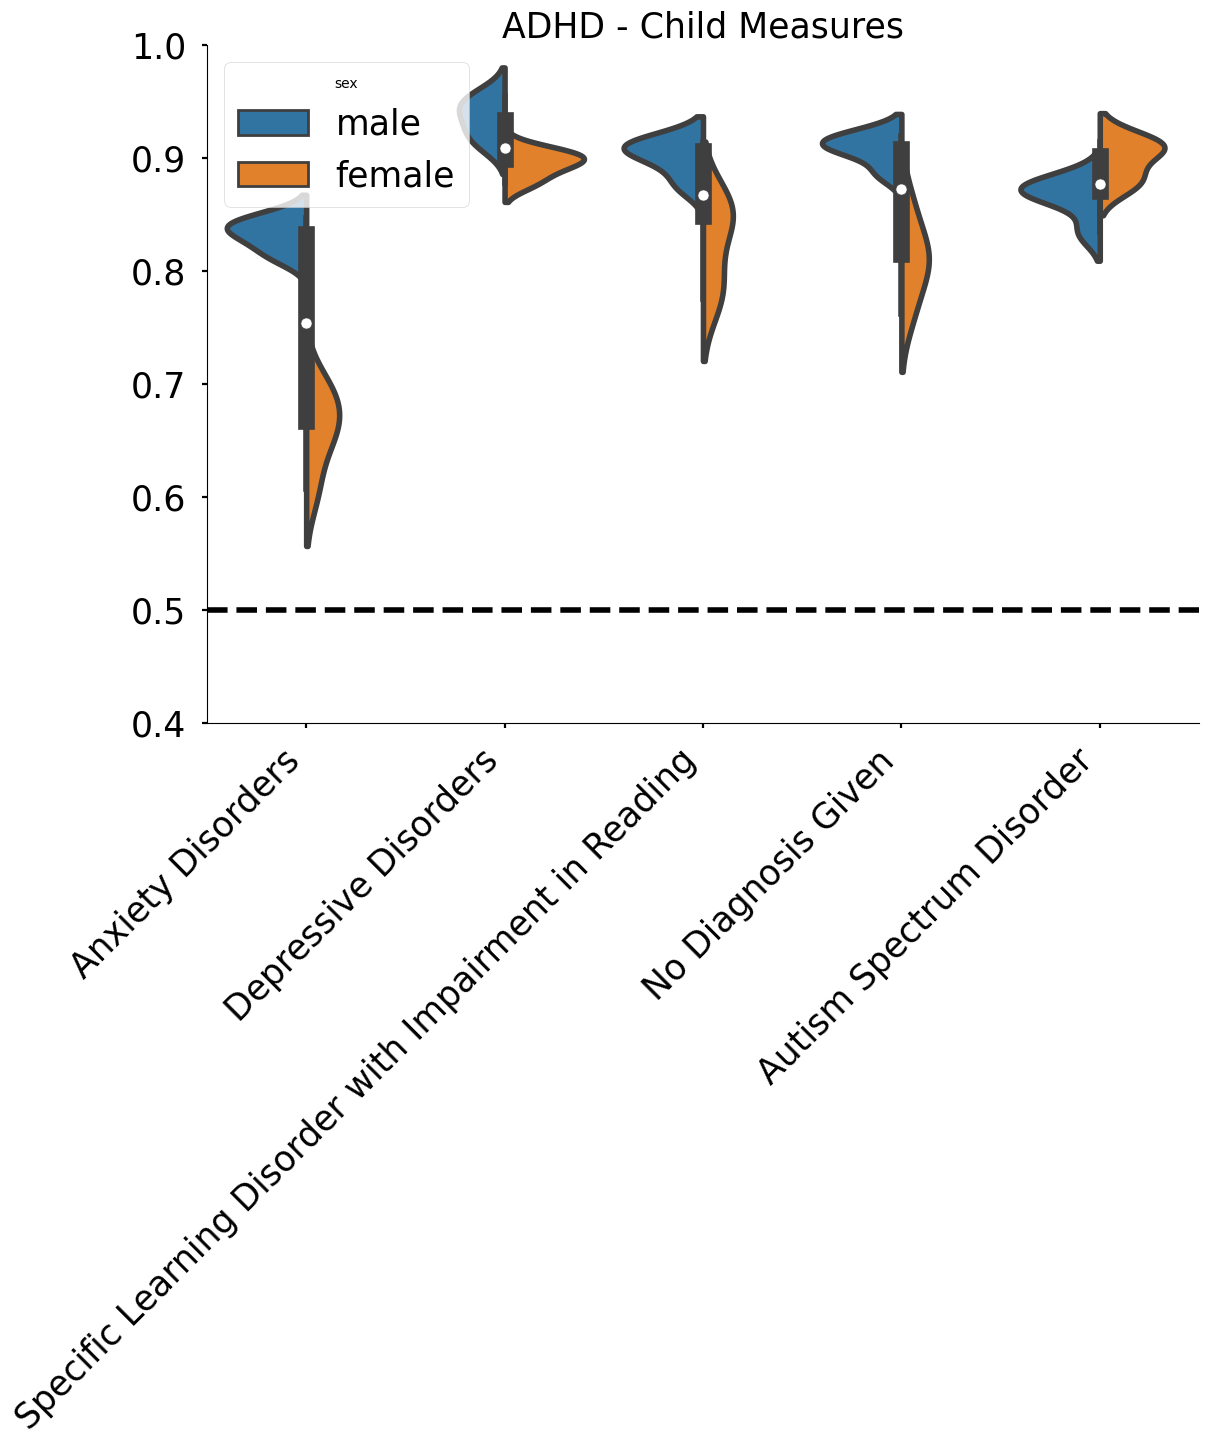

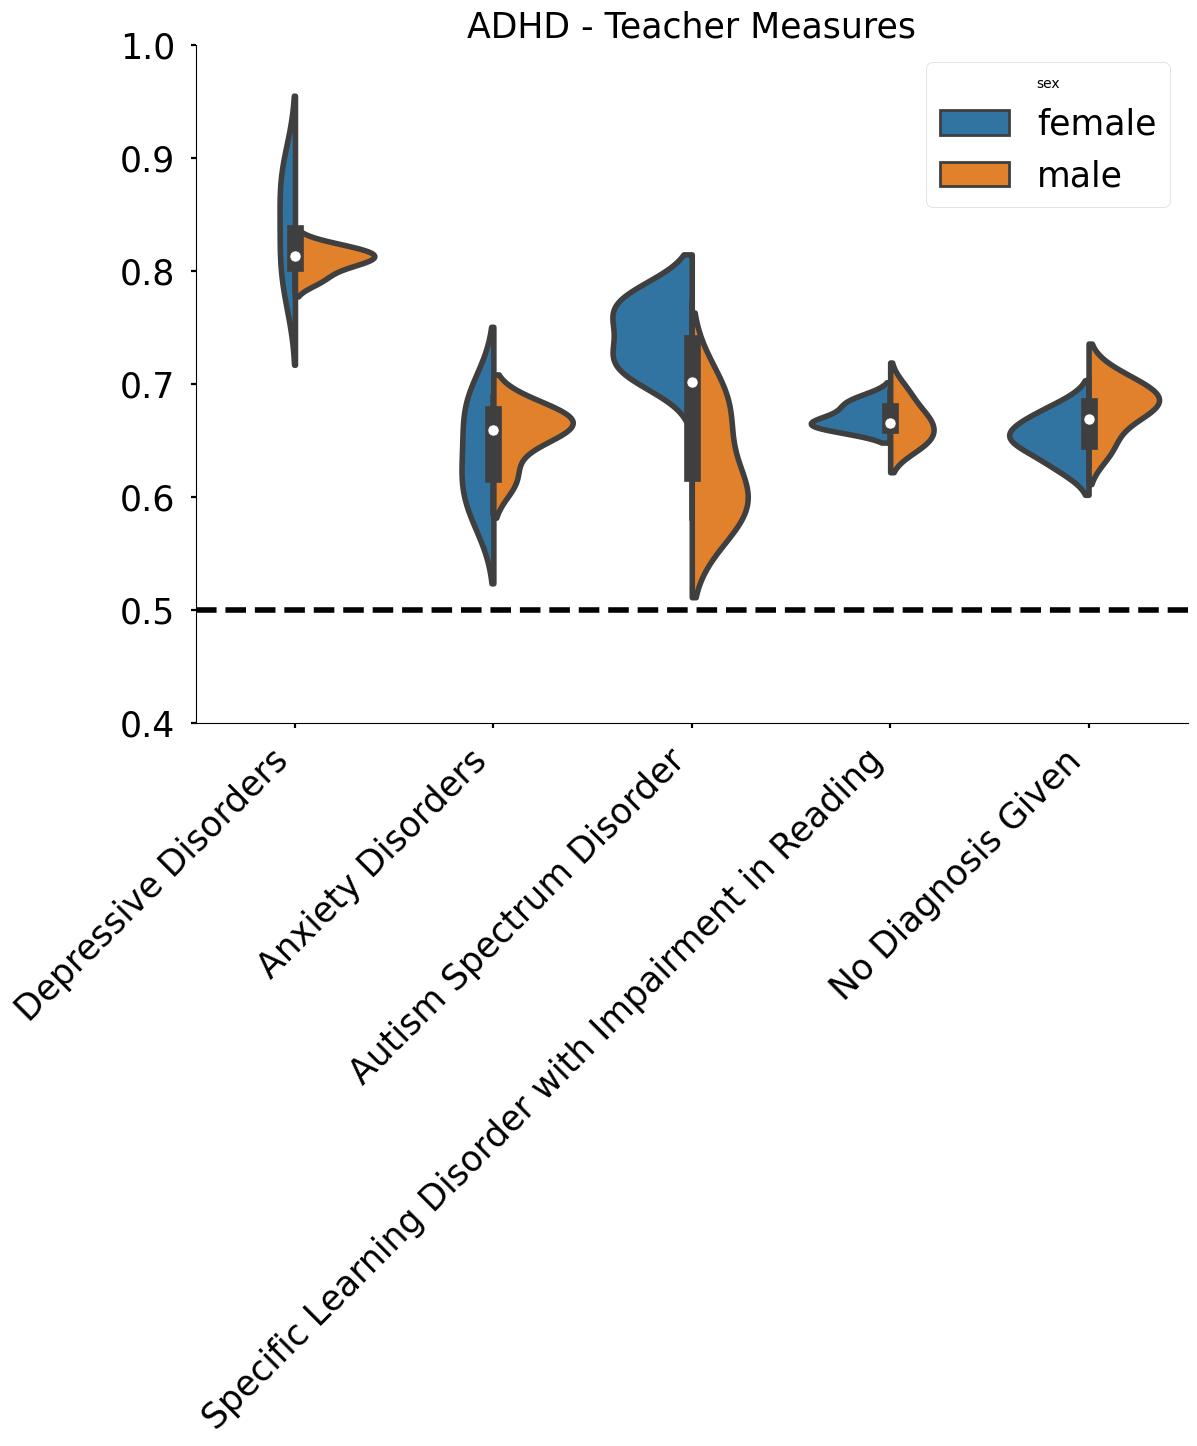

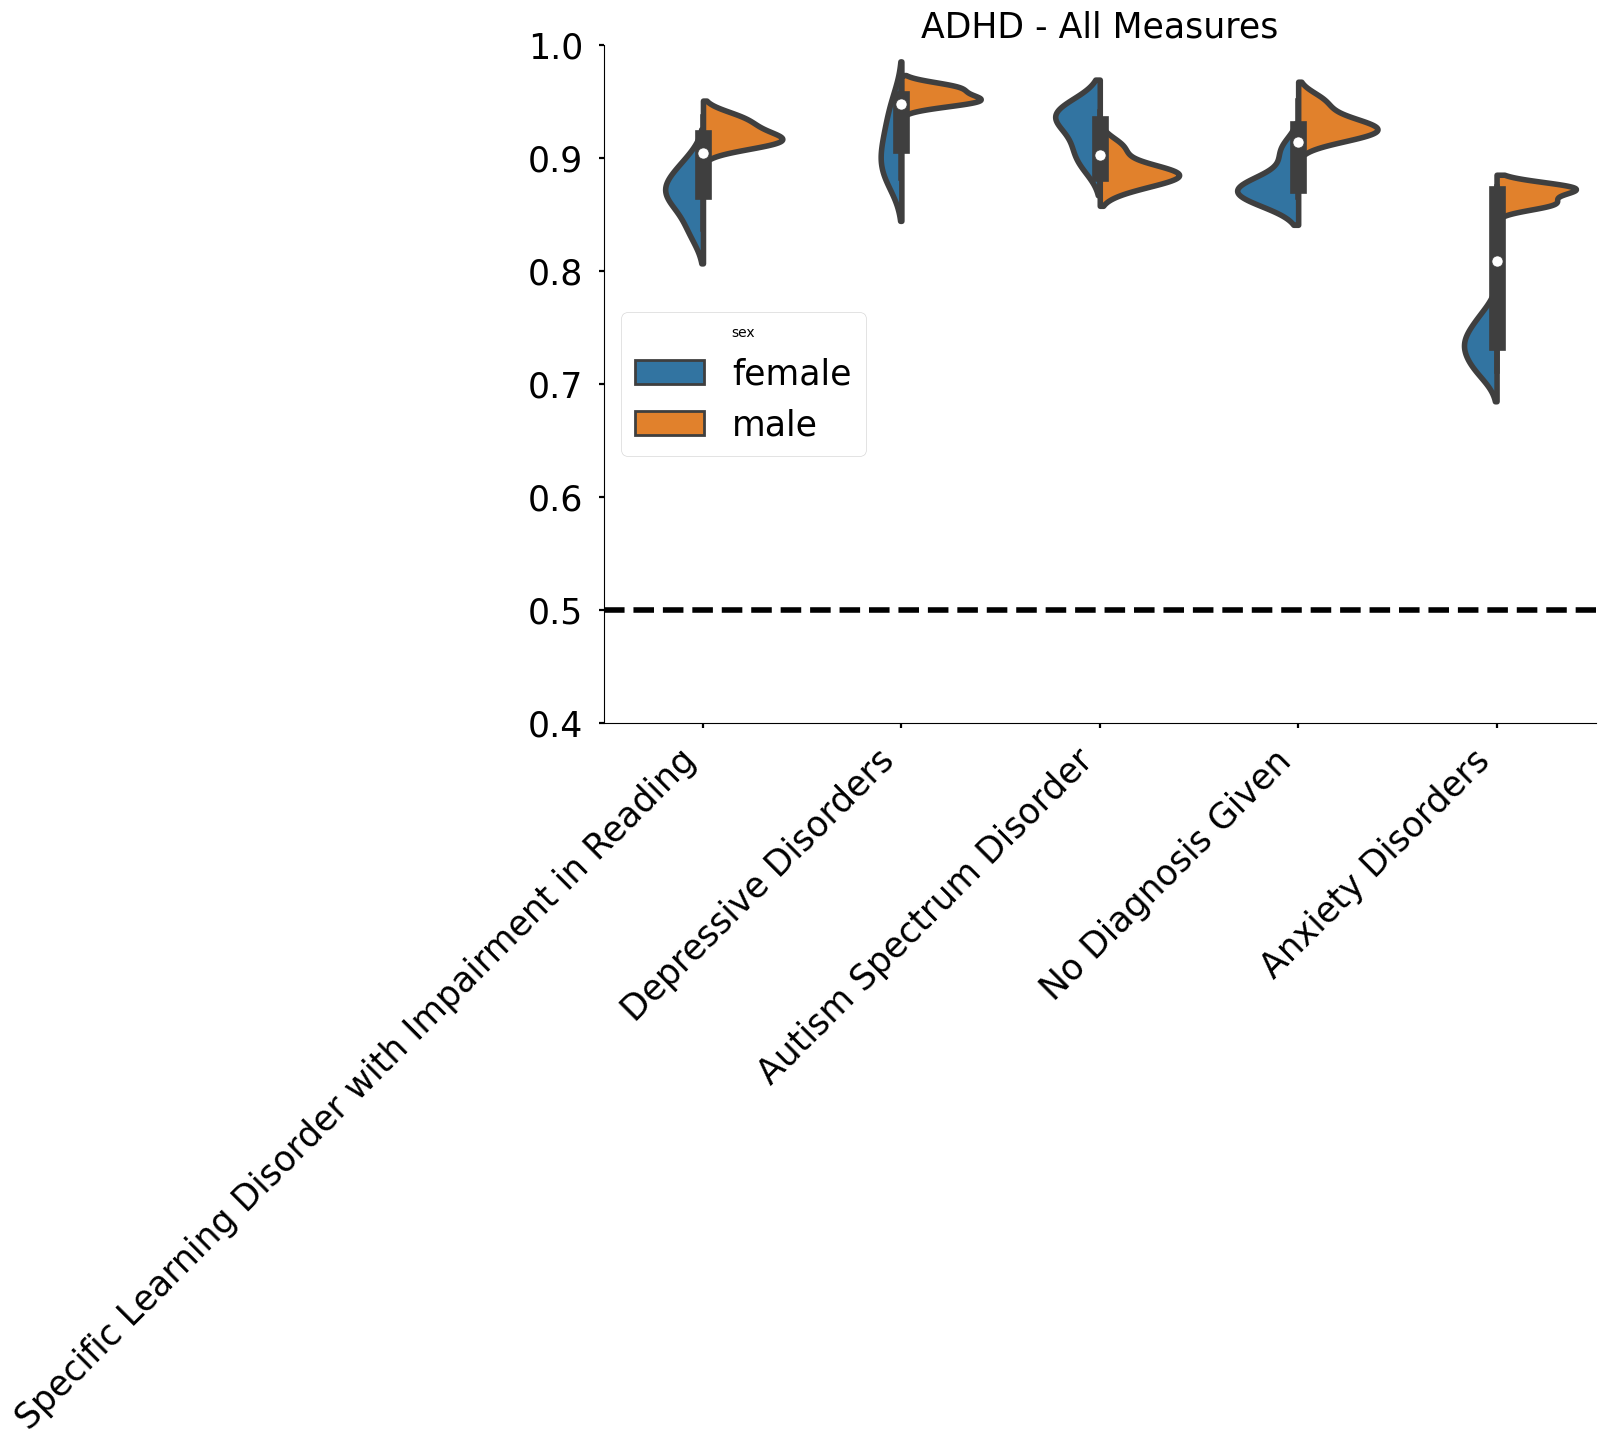

In [436]:
to_keep = ['Depressive Disorders', 'Anxiety Disorders', 'Autism Spectrum Disorder', 
           'Specific Learning Disorder with Impairment in Reading', 'No Diagnosis Given']

# PARENT MEASURES
df1 = df_all[(df_all['sex'].isin(['male', 'female'])) &
             (df_all['data']=='data') &
             (df_all['assessment']=='Parent Measures') &
             (df_all['category_new'].isin(to_keep))
            ].reset_index(drop=True)


ax = sns.violinplot(x='category_new', y='roc_auc_score', hue='sex', split=True, data=df1)
plt.xticks(rotation=45, ha='right')
ax.set_xlabel('')
ax.set_ylabel('')
ax.set_title('ADHD - Parent Measures')
plt.axhline(y=0.5, color='k', linestyle='--')
ax.set_ylim([0.4, 1])
plt.show()

# CHILD MEASURES
df1 = df_all[(df_all['sex'].isin(['male', 'female'])) &
             (df_all['data']=='data') &
             (df_all['assessment']=='Child Measures') &
             (df_all['category_new'].isin(to_keep))
            ].reset_index(drop=True)

ax = sns.violinplot(x='category_new', y='roc_auc_score', hue='sex', split=True, data=df1)
plt.xticks(rotation=45, ha='right')
ax.set_xlabel('')
ax.set_ylabel('')
ax.set_title('ADHD - Child Measures')
plt.axhline(y=0.5, color='k', linestyle='--')
ax.set_ylim([0.4, 1])
plt.show()

# TEACHER MEASURES
df1 = df_all[(df_all['sex'].isin(['male', 'female'])) &
             (df_all['data']=='data') &
             (df_all['assessment']=='Teacher Measures') &
             (df_all['category_new'].isin(to_keep))
            ].reset_index(drop=True)

ax = sns.violinplot(x='category_new', y='roc_auc_score', hue='sex', split=True, data=df1)
plt.xticks(rotation=45, ha='right')
ax.set_xlabel('')
ax.set_ylabel('')
ax.set_title('ADHD - Teacher Measures')
plt.axhline(y=0.5, color='k', linestyle='--')
ax.set_ylim([0.4, 1])
plt.show()

# ALL MEASURES
df1 = df_all[(df_all['sex'].isin(['male', 'female'])) &
             (df_all['data']=='data') &
             (df_all['assessment']=='all') &
             (df_all['category_new'].isin(to_keep))
            ].reset_index(drop=True)

ax = sns.violinplot(x='category_new', y='roc_auc_score', hue='sex', split=True, data=df1)
plt.xticks(rotation=45, ha='right')
ax.set_xlabel('')
ax.set_ylabel('')
ax.set_title('ADHD - All Measures')
plt.axhline(y=0.5, color='k', linestyle='--')
ax.set_ylim([0.4, 1])
plt.show()